Loaded data
Scaler data
PCA data
Label Encoder
Intializing SVM
Standard Scaler
SVM done
LinearSVC Accuracy: 68.70%


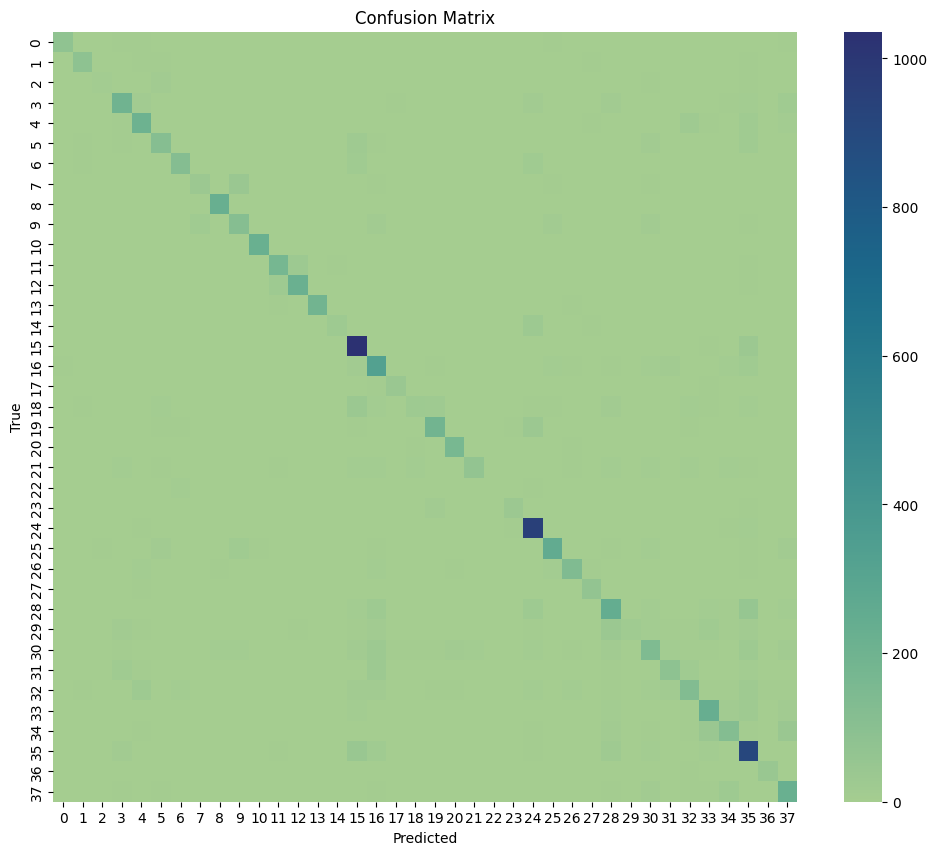

In [1]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import os
from glob import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_SIZE = (64, 64)

def Load_data(directory):
    X, y = [], []
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        for img_path in glob(os.path.join(class_path, "*.*")):
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, TARGET_SIZE)
            X.append(img.flatten())
            y.append(class_name)
    return np.array(X), np.array(y)

# Load data
X, y = Load_data("../input/plantvillage-dataset/color")

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4, stratify=y
)

print("Loaded data")
# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaler data")

# 🔥 PCA (major speed-up)
pca = PCA(n_components=300, random_state=42)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("PCA data")

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Label Encoder")
# Fast SVM
svm = LinearSVC(
    C=1.0,
    max_iter=3000,
    dual=False,
    tol=1e-3,
    random_state=4
)

print("Intializing SVM")
svm.fit(X_train, y_train_enc)

print("Standard Scaler")

# Evaluate
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test_enc, y_pred)

print("SVM done")
print(f"LinearSVC Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="crest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("LinearSVC.png")
plt.show()
